In [2]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

from matplotlib import pyplot as plt
from matplotlib_venn import venn3

import statsmodels.api as sm

import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [16]:
df = pd.read_parquet("/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_27_03_2026_with_MEM_EVI.parquet")
df = df[(df.year_week >= "2022-42") & (df.year_week <= "2025-32")]

In [17]:
dta = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/cities_valid_for_MEM_26_03_2026.parquet')

# Select cities valid for MEM

In [18]:
lst = list(set(df.co_ibge.unique()) - set(dta.co_ibge.unique()))
df = df[~df.co_ibge.isin(lst)]
data = df[(df.year_week >= '2025-01' )]

# Começa as analises

In [19]:
data.columns

Index(['co_uf', 'nm_uf', 'nm_municipio', 'co_ibge', 'epiyear', 'epiweek',
       'year_week', 'atend_totais', 'atend_ivas',
       'mem_surge_01_correct_with_consec', 'warning_final_mem_surge_01',
       'sinal_evi_ivas', 'EWS_ISF_atend_ivas', 'EWS_LOF_atend_ivas',
       'EWS_OCSVM_atend_ivas', 'EWS_COPOD_atend_ivas', 'EWS_Rt_atend_ivas'],
      dtype='object')

In [20]:
data.warning_final_mem_surge_01.sum()

5765

In [21]:
data.mem_surge_01_correct_with_consec.sum()

33083

In [22]:
data.sinal_evi_ivas.sum()

19484

In [23]:
#data[data.co_ibge == 530010]

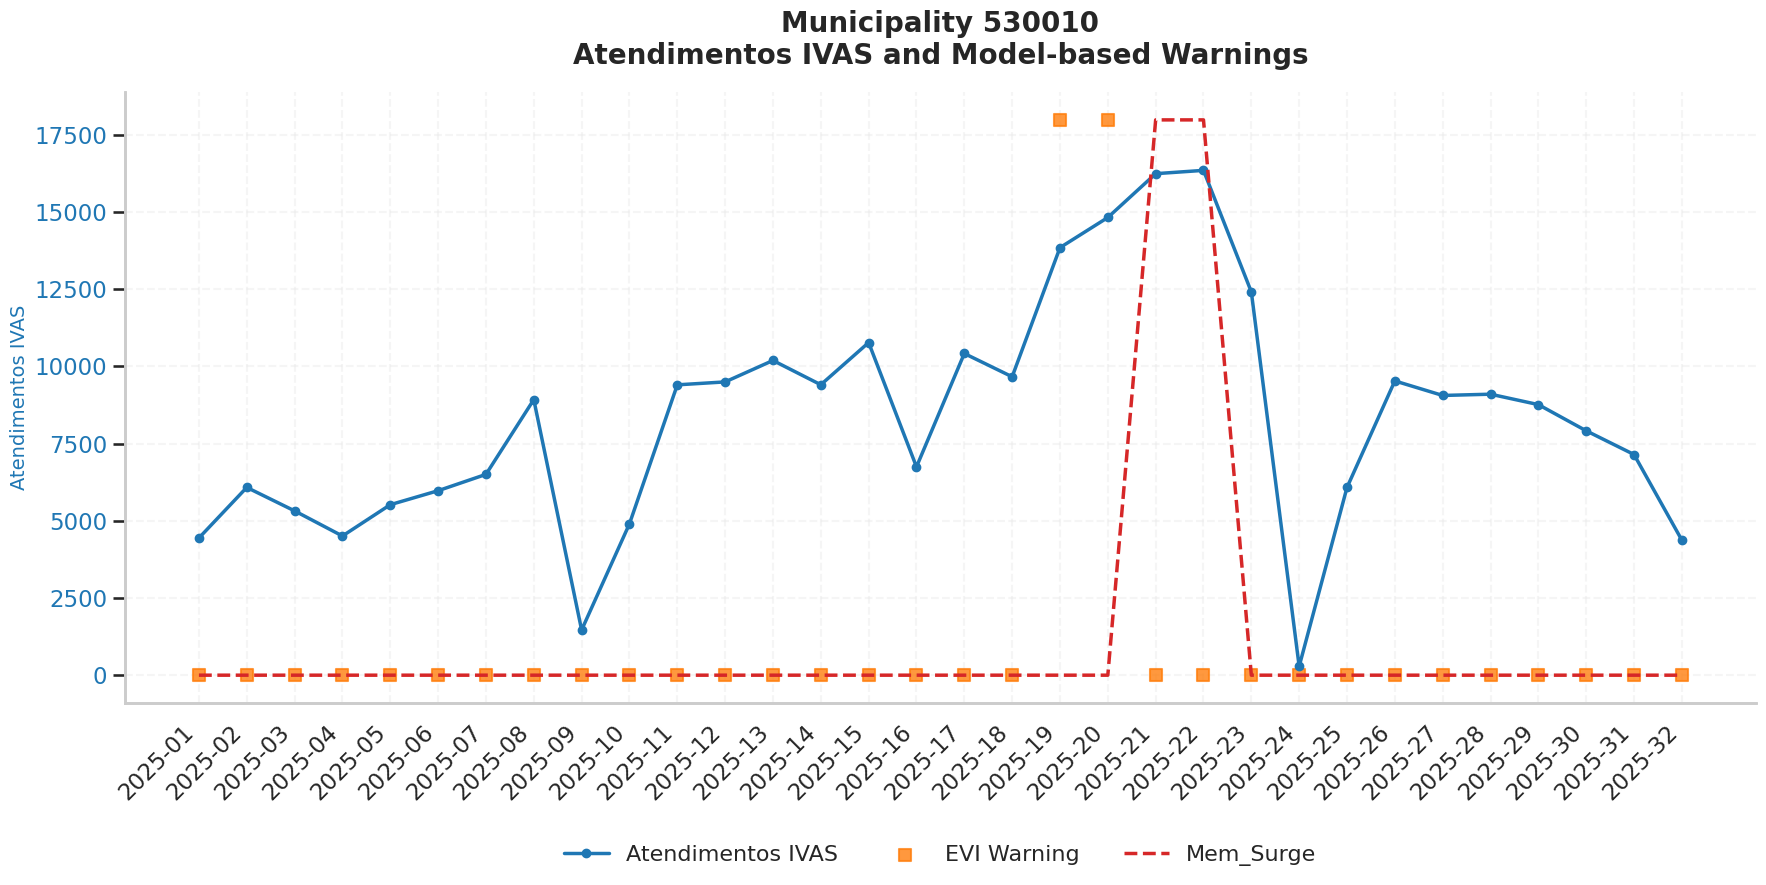

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot for one municipality ---
muni = 530010 # code
plotdf = data[data["co_ibge"] == muni].copy()

# Subtle, clean style
sns.set(style="whitegrid", context="talk")
sns.set_style("whitegrid", {"axes.grid": True, "grid.linestyle": "--", "grid.color": "0.9"})

fig, ax1 = plt.subplots(figsize=(18, 9))

# --- Main ILI line (Atend_ivas) ---
ax1.plot(
    plotdf["year_week"],
    plotdf["atend_ivas"],
    marker="o",
    color="#1f77b4",
    linewidth=2.5,
    markersize=6,
    label="Atendimentos IVAS"
)
ax1.set_ylabel("Atendimentos IVAS", color="#1f77b4", fontsize=14)
ax1.tick_params(axis="y", labelcolor="#1f77b4")

# --- Model warnings as markers ---
ymax = plotdf["atend_ivas"].max()

warnings = [
   # ("sinal_ears_ivas", 1.05, "^", "#2ca02c", "EARS Warning"),
    ("sinal_evi_ivas",  1.10, "s", "#ff7f0e", "EVI Warning"),
    #("sinal_mmaing_ivas", 1.15, "D", "#9467bd", "MMAING Warning"),
    #("sinal_ens_ivas",  1.20, "X", "#7f7f7f", "Dashboard Ensemble")
]

for col, mult, mark, colr, label in warnings:
    ax1.scatter(
        plotdf["year_week"],
        plotdf[col] * ymax * mult,
        marker=mark,
        color=colr,
        s=80,
        alpha=0.8,
        label=label
    )

# --- Secondary axis: memory surge (hidden axis) ---
ax2 = ax1.twinx()
ax2.plot(
    plotdf["year_week"],
    plotdf["mem_surge_01_correct_with_consec"], #warning_final_mem_surge_01
    color="#d62728",
    linestyle="--",
    linewidth=2.5,
    label="Mem_Surge"
)
# Make secondary axis silent
ax2.set_yticks([])
ax2.set_ylabel("")
ax2.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, labelright=False)
ax2.spines["right"].set_visible(False)

# --- Title and Legend ---
plt.title(
    f"Municipality {muni}\nAtendimentos IVAS and Model-based Warnings",
    fontsize=20, weight="bold", pad=20
)

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2, labels1 + labels2,
    loc="upper center", bbox_to_anchor=(0.5, -0.2),
    ncol=3, frameon=False, fontsize=16
)

# --- Final touches ---
ax1.grid(True, which="major", linestyle="--", alpha=0.4)
ax1.grid(False, which="minor")
fig.tight_layout()
fig.autofmt_xdate(rotation=45)
sns.despine(left=False, right=True)

plt.show()


# Functions

In [29]:
def antici_count(data_res, col_warn_s1, col_warn_s2,col_warn_s2_with_consec, col_code):
    """
    Function to compute anticipated counts of warnings and missed warnings 
    across different lead times per unique region.
    
    Parameters:
    data_res (pd.DataFrame): Input DataFrame.
    col_warn_s1 (str): Column name for the primary warning signal (e.g., PHC warnings).
    col_warn_s2 (str): Column name for the secondary warning signal (e.g., AIH warnings).
    col_code (str): Column name identifying the region.

    Returns:
    pd.DataFrame: Summary DataFrame with counts of early, concurrent, and missed warnings.
    """
    
    lst_count = []

    for code in data_res[col_code].unique():
    
        dta = data_res[data_res[col_code] == code].copy().reset_index()  # Use only data for the current region

        # encontra todos os surtos que estão sendo detectados 3 semanas antes
        set3 = dta[(dta[col_warn_s1] == 1) & (dta[col_warn_s2].shift(-3) == 1)].index + 3 
        # encontra todos os surtos que estão sendo detectados 2 semanas antes e excluindo aqueles que ja foram detectados 3 semanas antes
        set2 = dta[(dta[col_warn_s1] == 1) & (dta[col_warn_s2].shift(-3) == 0) & (dta[col_warn_s2].shift(-2) == 1)].index + 2
        # encontra todos os surtos que estão sendo detectados 1 semanas antes e excluindo os casos anteriores
        set1 = dta[(dta[col_warn_s1] == 1) & 
                   (dta[col_warn_s2].shift(-3) == 0) & 
                   (dta[col_warn_s2].shift(-2) == 0) & 
                   (dta[col_warn_s2].shift(-1) == 1)].index + 1
        # encontra todos os surtos que estão sendo detectados namesma semanas e excluindo os casos anteriores
        set0 = dta[(dta[col_warn_s1] == 1) & 
                   (dta[col_warn_s2] == 1) & 
                   (dta[col_warn_s2].shift(-3) == 0) & 
                   (dta[col_warn_s2].shift(-2) == 0) & 
                   (dta[col_warn_s2].shift(-1) == 0)].index
        
        # non surge weeks without alarm (Identify True Negatives (TN))
        set_tn1 = dta[(dta[col_warn_s2_with_consec] == 0) &  # aqui deveria usar a coluna com os avisos em blocos corrigidos col_warn_s2
                      (dta[col_warn_s1] == 0) & 
                      (dta[col_warn_s1].shift(1).fillna(0) == 0) & 
                      (dta[col_warn_s1].shift(2).fillna(0) == 0) & 
                      (dta[col_warn_s1].shift(3).fillna(0) == 0)
                    ].index
        
        # non-surge with alarms in the same or previous weeks
        set_fp1 = dta[(dta[col_warn_s2_with_consec] == 0) & # aqui deveria usar a coluna com os avisos em blocos corrigidos col_warn_s2
                   ((dta[col_warn_s1] == 1) | 
                   (dta[col_warn_s1].shift(3).fillna(0) == 1) | 
                   (dta[col_warn_s1].shift(2).fillna(0) == 1) | 
                   (dta[col_warn_s1].shift(1).fillna(0) == 1))].index

        # Warnings in PHC right after an AIH warning (possibly not anticipated but concurrent)
        set1_after = dta[(dta[col_warn_s1].shift(-1) == 1) & (dta[col_warn_s2] == 1)].index
        
       

        # Compute counts of warnings at different lead times
        n3 = len(set3)
        n2 = len(set(set2) - set(set3))
        n1 = len((set(set1) - set(set3)) - set(set2))
        n0 = len(((set(set0) - set(set3)) - set(set2)) - set(set1))
        n1_after = len((((set(set1_after) - set(set3)) - set(set2)) - set(set1)) - set(set0))
        n_tn1 = len(set_tn1) 
        n_fp1 = len(set_fp1)

        # Drop all anticipated and concurrent warnings to count missed ones
        ind_drop = set(set3) | set(set2) | set(set1) | set(set0) #| set(set1_after)
        missed = dta.drop(index=ind_drop)[col_warn_s2].sum()
        
        TP = n3 + n2 + n1 + n0
        
        # outra forma de calcular o FN
        #set_FN = dta[(dta[col_warn_s2] == 1) &  
        #           (dta[col_warn_s1] == 0) & 
        #           (dta[col_warn_s1].shift(3).fillna(0) == 0) & 
        #           (dta[col_warn_s1].shift(2).fillna(0) == 0) & 
        #           (dta[col_warn_s1].shift(1).fillna(0) == 0)].index
        
        
        # Create the results dictionary for this region
        data = {
            col_code: [code],
            'n3': [n3],
            'n2': [n2],
            'n1': [n1],
            'n0': [n0],
            'n1_after': [n1_after],
            'missed': [missed],
            'TP': [TP],
            'TN1': [n_tn1], # True Negative
            'FP1': [n_fp1], # False Positive
            'FN': missed,
            'total_aih_warning': [dta[col_warn_s2].sum()]
        }

        # Append to results list
        data_output = pd.DataFrame(data)
        lst_count.append(data_output)

    # Combine all results into a single DataFrame
    df_warning_count = pd.concat(lst_count, ignore_index=True)
    
    return df_warning_count


In [33]:
def summarize_performance(df_warning_count):
    """
    Summarizes performance metrics including Sensitivity, Specificity, PPV, F1-score, POD, and FPR.
    
    Parameters:
    df_warning_count (pd.DataFrame): Dataframe containing warning counts and classification metrics.
    
    Returns:
    pd.DataFrame: Summary table with performance metrics.
    """
    # Total AIH Warnings
    total_warnings = df_warning_count.total_aih_warning.sum()
    
    # Early Detection (1 to 3 weeks)
    early_count = df_warning_count.n3.sum() + df_warning_count.n2.sum() + df_warning_count.n1.sum()
    early_rate = round((early_count * 100) / total_warnings, 1)
    
    # Timely Detection (0 week)
    timely_count = df_warning_count.n0.sum()
    timely_rate = round((timely_count * 100) / total_warnings, 1)
    
    # Missed Warnings
    missed_count = df_warning_count.missed.sum()
    missed_rate = round((missed_count * 100) / total_warnings, 1)
    
    # Classification Metrics
    TP = df_warning_count.TP.sum()
    FN = df_warning_count.FN.sum()
    TN = df_warning_count.TN1.sum()
    FP = df_warning_count.FP1.sum()

    
    # Sensitivity (Recall)
    Sensitivity = round((TP / (TP + FN)) * 100, 1) if (TP + FN) > 0 else 0
    
    # Specificity
    Specificity = round((TN / (TN + FP)) * 100, 1) if (TN + FP) > 0 else 0
    
    # Positive Predictive Value (PPV)
    PPV = round((TP / (TP + FP)) * 100, 1) if (TP + FP) > 0 else 0

    # Positive Predictive Value (PPV)
    NPV = round((TN / (TN + FN)) * 100, 1) if (TN + FN) > 0 else 0
    
    # F1-score
    F1_score = round(2 * (TP / (TP + FN)) * (TP / (TP + FP)) / ((TP / (TP + FN)) + (TP / (TP + FP))), 2) if ((TP / (TP + FN)) + (TP / (TP + FP))) > 0 else 0
    
    Precision = round(((TP + TN) / (TP + TN + FP + FN) * 100), 1) if (TP + TN + FP + FN) > 0 else 0

    # Probability of Detection (POD)
    POD = round(((early_count + timely_count + df_warning_count.n1_after.sum()) / total_warnings) * 100, 1)
    
    # False Positive Rate (FPR)
    FPR = round((FP / (FP + TN)) * 100, 1) if (FP + TN) > 0 else 0
    
    # Create summary DataFrame
    summary_df = pd.DataFrame({
        "Metric": ["Total Warnings", "Early Detection (1-3 weeks)", "Timely Detection (0 weeks)", "Missed Warnings",
                   "Sensitivity ", "Specificity", "PPV",  "NPV", "POD", "FPR","Precision (%)"],
        "Value": [total_warnings, f"{early_count} ({early_rate}%)", f"{timely_count} ({timely_rate}%)", f"{missed_count} ({missed_rate}%)",
                   f"{Sensitivity}%", f"{Specificity}%", f"{PPV}%", f"{NPV}%",f"{POD}%", f"{FPR}%", f"{Precision}%"]
    })
    
    return summary_df



In [34]:
data.columns

Index(['co_uf', 'nm_uf', 'nm_municipio', 'co_ibge', 'epiyear', 'epiweek',
       'year_week', 'atend_totais', 'atend_ivas',
       'mem_surge_01_correct_with_consec', 'warning_final_mem_surge_01',
       'sinal_evi_ivas', 'EWS_ISF_atend_ivas', 'EWS_LOF_atend_ivas',
       'EWS_OCSVM_atend_ivas', 'EWS_COPOD_atend_ivas', 'EWS_Rt_atend_ivas'],
      dtype='object')

In [35]:
df_warning_count = antici_count(data, 'sinal_evi_ivas', 'warning_final_mem_surge_01','mem_surge_01_correct_with_consec', 'co_ibge')
performance_summary = summarize_performance(df_warning_count)
performance_summary

,Metric,Value
0,Total Warnings,5765
1,Early Detection (1-3 weeks),1864 (32.3%)
2,Timely Detection (0 weeks),2797 (48.5%)
3,Missed Warnings,1104 (19.2%)
4,Sensitivity,80.8%
5,Specificity,75.7%
6,PPV,12.1%
7,NPV,99.0%
8,POD,85.9%
9,FPR,24.3%


# Study peformance in relation to intensity

In [8]:
df_mem = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/mem_output_26_03_2026.parquet')

df_mem = df_mem[df_mem.epiyear.isin([2022,2023, 2024,2025])]

In [9]:
dta_intens = df_mem.groupby(['co_ibge'])[['baseline', 'post_baseline', 'epidemic_threshold',
       'post_threshold', 'low_level', 'medium_level', 'high_level']].max().reset_index()

In [10]:
# FUNCTION TO ASSIGN INTENSITY

def classify_block(values):
    
    # Check from most severe to least
    if (values > high).any():
        return 'very high'
    
    elif (values > med).any():
        return 'high'
    
    elif (values > low).any():
        return 'medium'
    
    elif (values > epi).any():
        return 'low'
    
    elif ((values > base) & (values <= epi)).any():
        return 'very low'
    
    elif (values <= base).any():
        return 'baseline'
    
    return np.nan

In [11]:
import warnings
warnings.filterwarnings('ignore')

lst = []

for code in data.co_ibge.unique():

    #print(code)

    set_muni = data[data.co_ibge == code].copy()
    set_muni_inten = dta_intens[dta_intens.co_ibge == code]

    thresholds = set_muni_inten.iloc[0]

    base = thresholds['baseline'].astype(int)
    epi = thresholds['epidemic_threshold'].astype(int)
    low = thresholds['low_level'].astype(int)
    med = thresholds['medium_level'].astype(int)
    high = thresholds['high_level'].astype(int)
    very_high = thresholds.get('very_high_level', np.inf)  # fallback if missing


    set_muni = set_muni.sort_values(['year_week'])

    # IDENTIFY BLOCKS

    flag = set_muni['mem_surge_01_correct_with_consec']

    # Create block IDs for consecutive 1s
    set_muni['block'] = (flag != flag.shift()).cumsum()

    # Keep only blocks where flag == 1
    set_muni['intensity'] = np.nan


    #  APPLY TO EACH BLOCK

    for block_id, group in set_muni.groupby('block'):
    
        if group['mem_surge_01_correct_with_consec'].iloc[0] != 1:
            continue
    
        values = group['atend_ivas']
    
        intensity_label = classify_block(values)
    
        set_muni.loc[group.index, 'intensity'] = intensity_label

    lst.append(set_muni)


In [12]:
result = pd.concat(lst)
result['mem_low'] = ((result['intensity'] == 'low') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_medium'] = ((result['intensity'] == 'medium') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_high'] = ((result['intensity'] == 'high') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_very_high'] = ((result['intensity'] == 'very high') & (result['warning_final_mem_surge_01'] == 1)).astype(int)

In [13]:
df_warning_count = antici_count(result, 'sinal_evi_ivas', 'mem_low', 'co_ibge')
performance_summary = summarize_performance(df_warning_count)
performance_summary

,Metric,Value
0,Total Warnings,1422
1,Early Detection (1-3 weeks),463 (32.6%)
2,Timely Detection (0 weeks),375 (26.4%)
3,Missed Warnings,584 (41.1%)
4,Sensitivity,58.9%
5,Specificity,57.2%
6,PPV,1.1%
7,POD,75.2%
8,FPR,42.8%
9,Precision (%),57.2%


In [71]:
df_warning_count = antici_count(result, 'sinal_evi_ivas', 'mem_medium', 'co_ibge')
performance_summary = summarize_performance(df_warning_count)
performance_summary

,Metric,Value
0,Total Warnings,1498
1,Early Detection (1-3 weeks),525 (35.0%)
2,Timely Detection (0 weeks),439 (29.3%)
3,Missed Warnings,534 (35.6%)
4,Sensitivity,64.4%
5,Specificity,57.3%
6,PPV,1.3%
7,POD,80.3%
8,FPR,42.7%
9,Precision (%),57.3%


In [72]:
df_warning_count = antici_count(result, 'sinal_evi_ivas', 'mem_high', 'co_ibge')
performance_summary = summarize_performance(df_warning_count)
performance_summary

,Metric,Value
0,Total Warnings,732
1,Early Detection (1-3 weeks),244 (33.3%)
2,Timely Detection (0 weeks),235 (32.1%)
3,Missed Warnings,253 (34.6%)
4,Sensitivity,65.4%
5,Specificity,57.2%
6,PPV,0.6%
7,POD,85.4%
8,FPR,42.8%
9,Precision (%),57.2%


In [73]:
df_warning_count = antici_count(result, 'sinal_evi_ivas', 'mem_very_high', 'co_ibge')
performance_summary = summarize_performance(df_warning_count)
performance_summary

,Metric,Value
0,Total Warnings,2113
1,Early Detection (1-3 weeks),714 (33.8%)
2,Timely Detection (0 weeks),793 (37.5%)
3,Missed Warnings,606 (28.7%)
4,Sensitivity,71.3%
5,Specificity,57.4%
6,PPV,2.0%
7,POD,89.9%
8,FPR,42.6%
9,Precision (%),57.6%
